In [2]:
# 1.导入库
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams # 字体
# 设置中文字体（Mac）
rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang SC', 'STHeiti']
rcParams['axes.unicode_minus'] = False   # 解决负号显示问题

In [3]:
# 2.导入数据
df = pd.read_csv('food_delivery_analytics_cleaned.csv')

In [4]:
# 3.数据概览
print('总记录数：',len(df))
print('总记录数：',len(df.columns))
print(df.columns)
print(df.info())          # 查看数据类型
print(df.describe())      # 数值列统计

总记录数： 15000
总记录数： 30
Index(['order_id', 'city_tier', 'customer_age', 'customer_loyalty_score',
       'order_hour', 'order_day_of_week', 'order_month',
       'delivery_distance_km', 'preparation_time_minutes',
       'delivery_time_minutes', 'estimated_delivery_time',
       'traffic_level_score', 'weather_severity_score', 'restaurant_rating',
       'delivery_partner_rating', 'customer_rating', 'order_value',
       'delivery_fee', 'discount_amount', 'tip_amount', 'final_amount_paid',
       'number_of_items', 'cancellation_flag', 'delayed_delivery_flag',
       'refund_flag', 'promo_code_used', 'premium_customer_flag',
       'festival_or_weekend_flag', 'delivery_partner_experience_years',
       'delivery_efficiency_score'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0

In [5]:
# 4.数据清洗
print(df.isna().sum())    # 查看缺失值
missing = df.isnull().mean() # 查看缺失值比例
print(missing[missing > 0])

order_id                               0
city_tier                              0
customer_age                           0
customer_loyalty_score                 0
order_hour                             0
order_day_of_week                      0
order_month                            0
delivery_distance_km                   0
preparation_time_minutes               0
delivery_time_minutes                  0
estimated_delivery_time                0
traffic_level_score                    0
weather_severity_score                 0
restaurant_rating                      0
delivery_partner_rating              150
customer_rating                      150
order_value                            0
delivery_fee                           0
discount_amount                        0
tip_amount                           150
final_amount_paid                      0
number_of_items                        0
cancellation_flag                      0
delayed_delivery_flag                  0
refund_flag     

In [6]:
# 缺失值<5%可用均值填充（小于0.01也可以直接删除）
df['delivery_partner_rating'].fillna(df['delivery_partner_rating'].mean(), inplace=True)
df['customer_rating'].fillna(df['customer_rating'].mean(), inplace=True)
# 或者用等号赋值
# df['delivery_partner_rating'] = df['delivery_partner_rating'].fillna(df['delivery_partner_rating'].mean())
# df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].mean())

#小费用0填充
df['tip_amount'].fillna(0, inplace=True)

In [7]:
# 检查是否有重复值
df.duplicated().sum()

0

延迟订单占比：9.47%


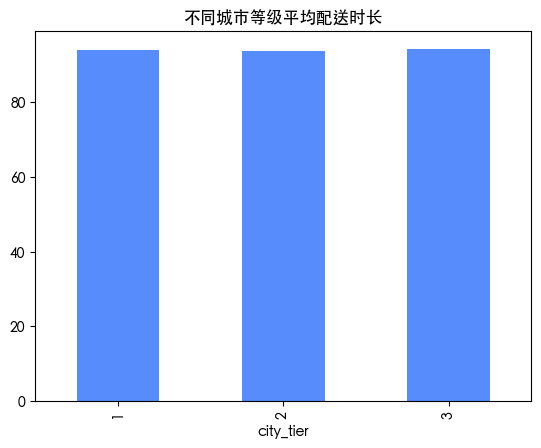

In [8]:
# 5.核心指标计算与可视化
# （1）配送效率分析
# 实际配送时长 vs 预计配送时长
df['delivery_diff'] = df['delivery_time_minutes'] - df['estimated_delivery_time']

# 延迟比例
delayed_rate = df['delayed_delivery_flag'].mean()
print(f"延迟订单占比：{delayed_rate:.2%}")

# 按城市等级看平均配送时长
df.groupby('city_tier')['delivery_time_minutes'].mean().plot(kind='bar')
plt.title('不同城市等级平均配送时长')
plt.show()

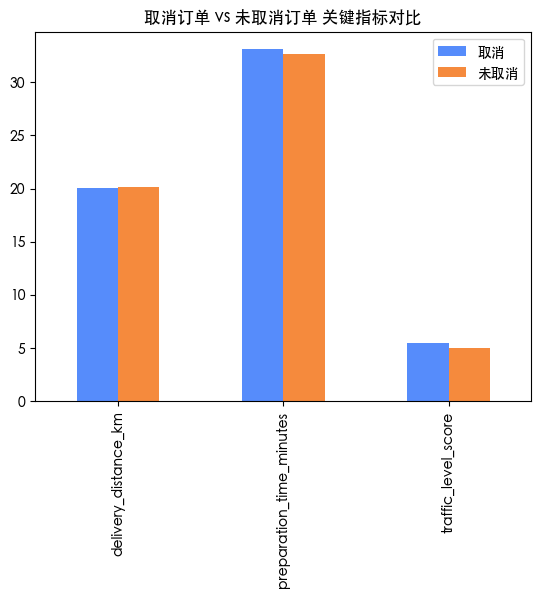

In [9]:
# （2）取消与退款原因探查
# 取消订单的特征对比
cancel_yes = df[df['cancellation_flag'] == 1]
cancel_no = df[df['cancellation_flag'] == 0]
# 对比两组在配送距离、备餐时间、交通评分等指标上的均值差异
features = ['delivery_distance_km', 'preparation_time_minutes', 'traffic_level_score']
pd.DataFrame({
    '取消': cancel_yes[features].mean(),
    '未取消': cancel_no[features].mean()
}).plot(kind='bar')
plt.title('取消订单 vs 未取消订单 关键指标对比')
plt.show()

<Axes: xlabel='customer_loyalty_score', ylabel='order_value'>

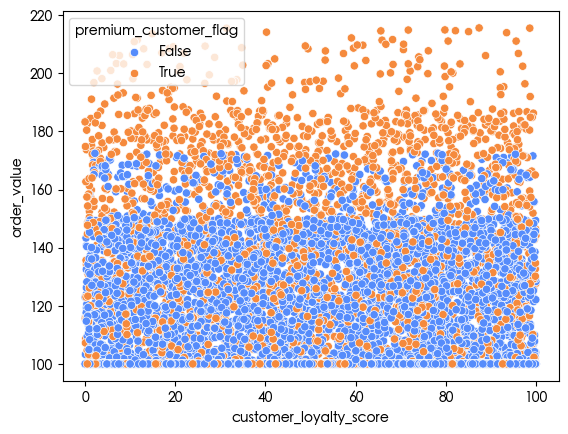

In [10]:
# （3）客户分层与价值分析
# 按会员标志、城市等级分组统计客单价
df.groupby(['premium_customer_flag', 'city_tier'])['order_value'].mean()

# 忠诚度评分与订单金额的关系
sns.scatterplot(x='customer_loyalty_score', y='order_value', hue='premium_customer_flag', data=df)

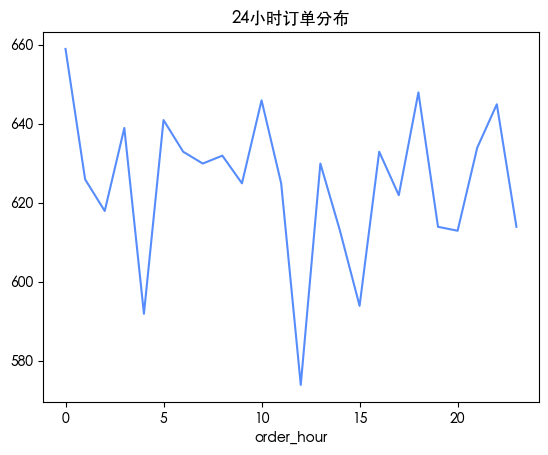

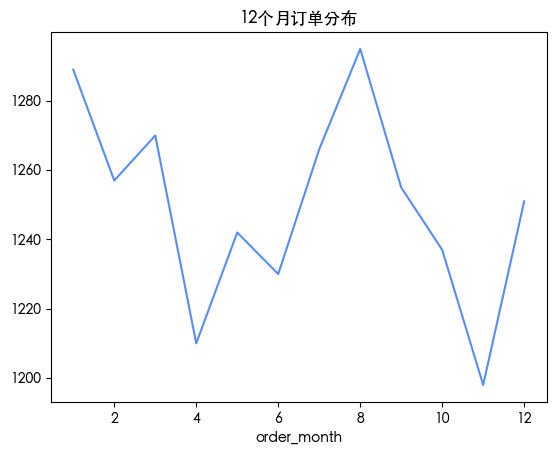

festival_or_weekend_flag
False    111.943313
True     121.714705
Name: order_value, dtype: float64

In [11]:
# （4）时间维度分析
# 不同小时/星期/月份的订单量
df['order_hour'].value_counts().sort_index().plot()
plt.title('24小时订单分布')
plt.show()

df['order_month'].value_counts().sort_index().plot()
plt.title('12个月订单分布')
plt.show()

# 节假日/周末 vs 平常的订单金额对比
df.groupby('festival_or_weekend_flag')['order_value'].mean()